In [1]:
import pandas as pd
import numpy as np

input_path = "/kaggle/input/datasets/luquang231/datathonvinu/"
# Load data
orders = pd.read_csv(input_path + "orders.csv", parse_dates=["order_date"])
order_items = pd.read_csv(input_path + "order_items.csv")
products = pd.read_csv(input_path + "products.csv")
customers = pd.read_csv(input_path + "customers.csv")
returns = pd.read_csv(input_path + "returns.csv")
web = pd.read_csv(input_path + "web_traffic.csv")
payments = pd.read_csv(input_path + "payments.csv")
geography = pd.read_csv(input_path + "geography.csv")
sales = pd.read_csv(input_path + "sales.csv")

# =====================
# Q1: median inter-order gap
# =====================
orders_sorted = orders.sort_values(["customer_id", "order_date"])
orders_sorted["prev_date"] = orders_sorted.groupby("customer_id")["order_date"].shift(1)
orders_sorted["gap"] = (orders_sorted["order_date"] - orders_sorted["prev_date"]).dt.days
q1 = orders_sorted["gap"].dropna().median()

# =====================
# Q2: best segment margin
# =====================
products["margin"] = (products["price"] - products["cogs"]) / products["price"]
q2 = products.groupby("segment")["margin"].mean().idxmax()

# =====================
# Q3: most common return reason (Streetwear)
# =====================
street = products[products["category"] == "Streetwear"]
ret_join = returns.merge(street, on="product_id")
q3 = ret_join["return_reason"].value_counts().idxmax()

# =====================
# Q4: lowest bounce rate
# =====================
q4 = web.groupby("traffic_source")["bounce_rate"].mean().idxmin()

# =====================
# Q5: % rows with promo
# =====================
q5 = order_items["promo_id"].notna().mean()

# =====================
# Q6: age group highest avg orders
# =====================
orders_per_customer = orders.groupby("customer_id").size()
cust_orders = customers.merge(orders_per_customer.rename("num_orders"), on="customer_id")
cust_orders = cust_orders.dropna(subset=["age_group"])
q6 = cust_orders.groupby("age_group")["num_orders"].mean().idxmax()

# =====================
# Q7: region highest revenue
# =====================
orders_geo = orders.merge(geography, on="zip")
orders_geo = orders_geo.merge(order_items, on="order_id")
orders_geo["revenue"] = orders_geo["quantity"] * orders_geo["unit_price"]
q7 = orders_geo.groupby("region")["revenue"].sum().idxmax()

# =====================
# Q8: payment method most in cancelled
# =====================
cancelled = orders[orders["order_status"] == "cancelled"]
q8 = cancelled["payment_method"].value_counts().idxmax()

# =====================
# Q9: size highest return rate
# =====================
oi_prod = order_items.merge(products, on="product_id")
returns_flag = returns[["order_id", "product_id"]]
oi_prod["returned"] = oi_prod.set_index(["order_id","product_id"]).index.isin(
    returns_flag.set_index(["order_id","product_id"]).index
)
q9 = oi_prod.groupby("size")["returned"].mean().idxmax()

# =====================
# Q10: installment highest avg payment
# =====================
q10 = payments.groupby("installments")["payment_value"].mean().idxmax()

# Print all answers
print("Q1:", q1)
print("Q2:", q2)
print("Q3:", q3)
print("Q4:", q4)
print("Q5:", q5)
print("Q6:", q6)
print("Q7:", q7)
print("Q8:", q8)
print("Q9:", q9)
print("Q10:", q10)

/tmp/ipykernel_55/2332075640.py:7: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  order_items = pd.read_csv(input_path + "order_items.csv")


Q1: 144.0
Q2: Standard
Q3: wrong_size
Q4: email_campaign
Q5: 0.3866349316956521
Q6: 55+
Q7: East
Q8: credit_card
Q9: S
Q10: 6


/tmp/ipykernel_55/3678851530.py:7: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  order_items = pd.read_csv(input_path + "order_items.csv")


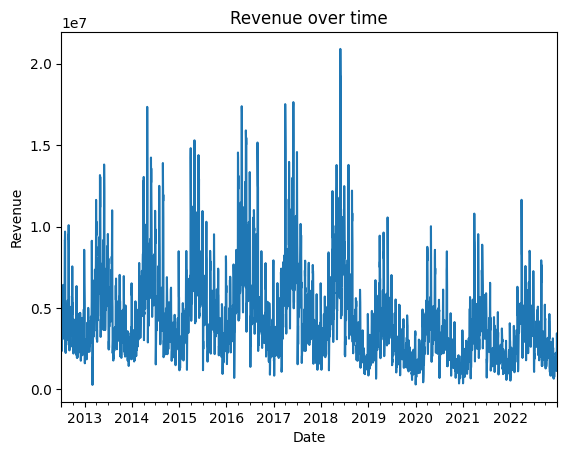

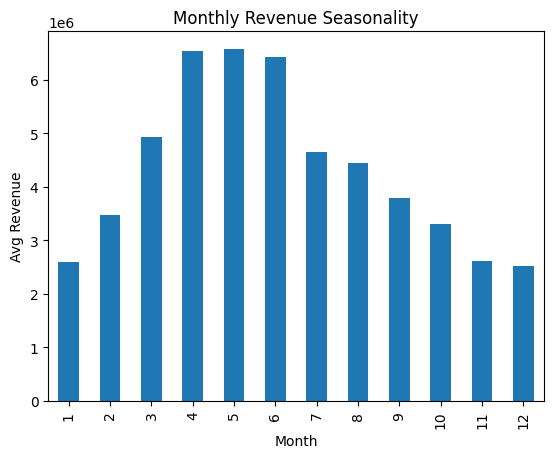

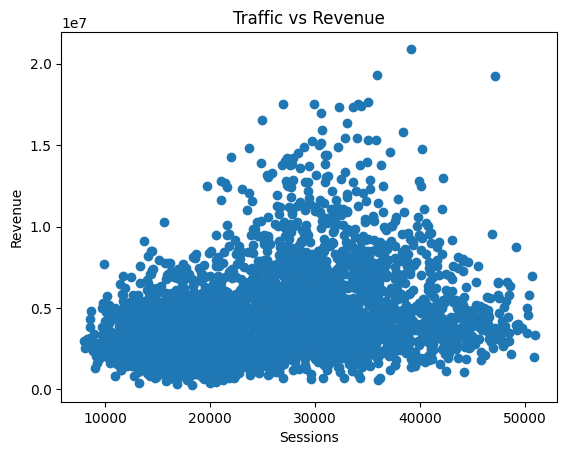

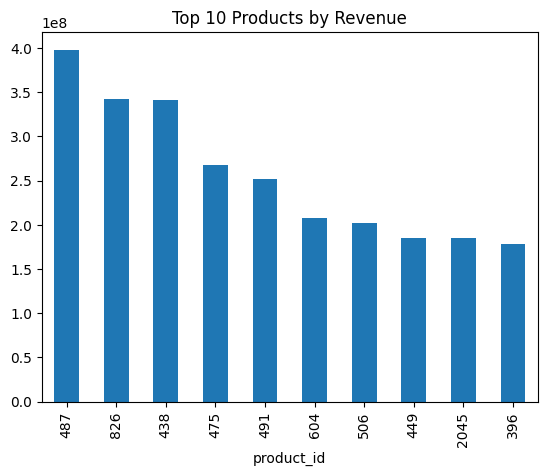

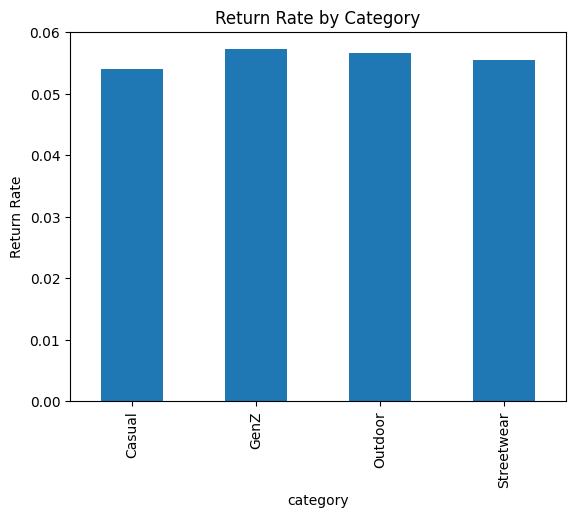

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

sales = pd.read_csv(input_path + "sales.csv", parse_dates=["Date"])
web = pd.read_csv(input_path + "web_traffic.csv", parse_dates=["date"])
orders = pd.read_csv(input_path + "orders.csv", parse_dates=["order_date"])
order_items = pd.read_csv(input_path + "order_items.csv")

# =====================
# Revenue over time
# =====================
plt.figure()
sales.set_index("Date")["Revenue"].plot()
plt.title("Revenue over time")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.show()

# =====================
# Monthly seasonality
# =====================
sales["month"] = sales["Date"].dt.month
monthly = sales.groupby("month")["Revenue"].mean()

plt.figure()
monthly.plot(kind="bar")
plt.title("Monthly Revenue Seasonality")
plt.xlabel("Month")
plt.ylabel("Avg Revenue")
plt.show()

# =====================
# Traffic vs Revenue
# =====================
web_daily = web.groupby("date")["sessions"].sum()
merged = sales.merge(web_daily, left_on="Date", right_on="date")

plt.figure()
plt.scatter(merged["sessions"], merged["Revenue"])
plt.title("Traffic vs Revenue")
plt.xlabel("Sessions")
plt.ylabel("Revenue")
plt.show()

# =====================
# Top products by revenue
# =====================
oi = order_items.copy()
oi["revenue"] = oi["quantity"] * oi["unit_price"]
top_products = oi.groupby("product_id")["revenue"].sum().nlargest(10)

plt.figure()
top_products.plot(kind="bar")
plt.title("Top 10 Products by Revenue")
plt.show()

# =====================
# Return rate by category
# =====================
products = pd.read_csv(input_path + "products.csv")
returns = pd.read_csv(input_path + "returns.csv")

oi_prod = order_items.merge(products, on="product_id")
oi_prod["returned"] = oi_prod.set_index(["order_id","product_id"]).index.isin(
    returns.set_index(["order_id","product_id"]).index
)

cat_return = oi_prod.groupby("category")["returned"].mean()

plt.figure()
cat_return.plot(kind="bar")
plt.title("Return Rate by Category")
plt.ylabel("Return Rate")
plt.show()

In [3]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor

# =====================
# Load train data
# =====================
df = pd.read_csv(input_path + "sales.csv", parse_dates=["Date"])
df = df.sort_values("Date")

# =====================
# Create future dates (test period)
# =====================
future_dates = pd.date_range(start="2023-01-01", end="2024-07-01")

future_df = pd.DataFrame({"Date": future_dates})

# =====================
# Feature engineering
# =====================
def create_features(df):
    df["year"] = df["Date"].dt.year
    df["month"] = df["Date"].dt.month
    df["day"] = df["Date"].dt.day
    df["dayofweek"] = df["Date"].dt.dayofweek
    df["weekofyear"] = df["Date"].dt.isocalendar().week.astype(int)
    return df

df = create_features(df)
future_df = create_features(future_df)

# =====================
# Lag features (train)
# =====================
for lag in [1, 7, 14, 30]:
    df[f"lag_{lag}"] = df["Revenue"].shift(lag)

df = df.dropna()

# =====================
# Train model
# =====================
features = [c for c in df.columns if c not in ["Date", "Revenue", "COGS"]]

X = df[features]
y = df["Revenue"]

model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X, y)

# =====================
# Predict future (rolling forecast)
# =====================
all_data = pd.concat([df, future_df], ignore_index=True)

for i in range(len(future_df)):
    idx = len(df) + i

    # tạo lag từ dữ liệu trước đó
    for lag in [1, 7, 14, 30]:
        all_data.loc[idx, f"lag_{lag}"] = all_data.loc[idx - lag, "Revenue"]

    row = all_data.loc[idx, features].values.reshape(1, -1)
    pred = model.predict(row)[0]

    all_data.loc[idx, "Revenue"] = pred

# =====================
# Extract prediction
# =====================
submission = all_data.iloc[len(df):][["Date", "Revenue"]]

# =====================
# Predict COGS (ratio)
# =====================
ratio = (df["COGS"] / df["Revenue"]).mean()
submission["COGS"] = submission["Revenue"] * ratio

# =====================
# Save submission
# =====================
submission.to_csv("submission.csv", index=False)

print("✅ Done! submission.csv ready")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/

✅ Done! submission.csv ready


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [9]:
print(geography.sample(4))

         zip       city   region      district
15145  28201  Hai Phong     East  District #11
32722  78013    Kon Tum  Central  District #23
12829  28411    Cam Pha     East  District #08
13802  31832     Phu Ly     East  District #09


/tmp/ipykernel_55/107144023.py:9: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  order_items = pd.read_csv(input_path + "order_items.csv")



Promo + Installment effect:
 has_promo  is_installment
False      False             24993.332807
           True              25143.569417
True       False             19490.447558
           True              19795.445360
Name: revenue, dtype: float64

Traffic vs Revenue correlation: 0.32105016128466324


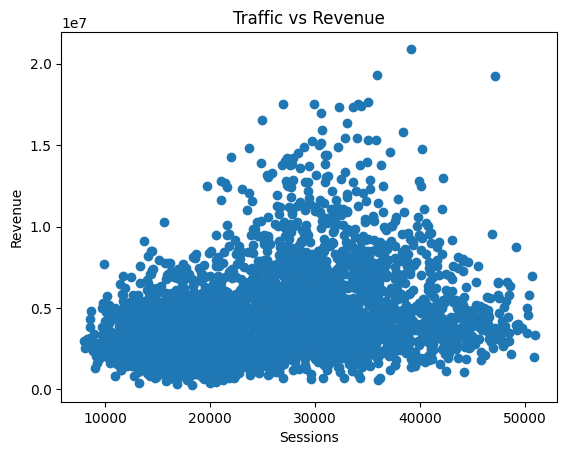

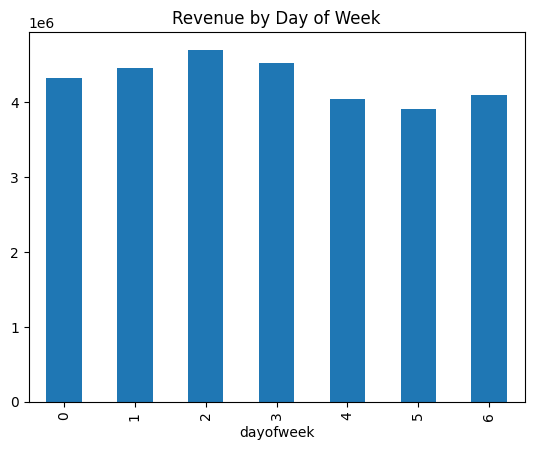


Return rate by category:
 category
GenZ          0.057214
Outdoor       0.056618
Streetwear    0.055393
Casual        0.053937
Name: returned, dtype: float64

Return rate by installment:
 is_installment
False    0.064386
True     0.050062
Name: returned, dtype: float64


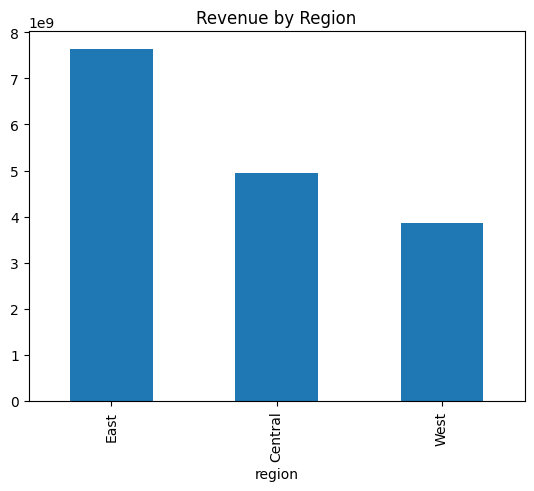

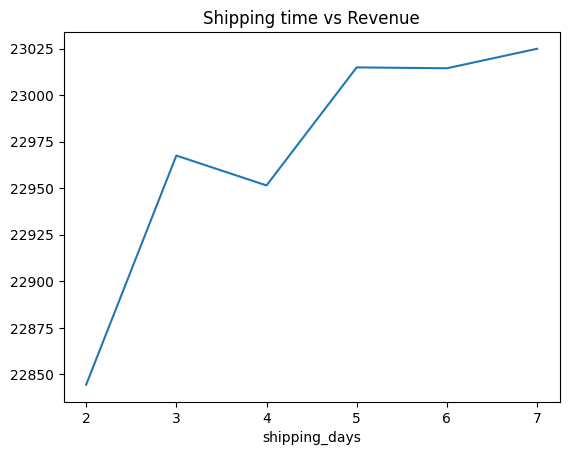


Promo type effect:
 promo_type
fixed         17970.106983
percentage    19810.639597
Name: revenue, dtype: float64

Min order value impact:
 min_order_value
(-200.0, 40000.0]       20735.444397
(40000.0, 80000.0]      15740.267179
(80000.0, 120000.0]     18403.507680
(120000.0, 160000.0]    18980.949026
(160000.0, 200000.0]    18473.013671
Name: revenue, dtype: float64


/tmp/ipykernel_55/107144023.py:125: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mov_effect = df.groupby(pd.cut(df["min_order_value"], bins=5))["revenue"].mean()


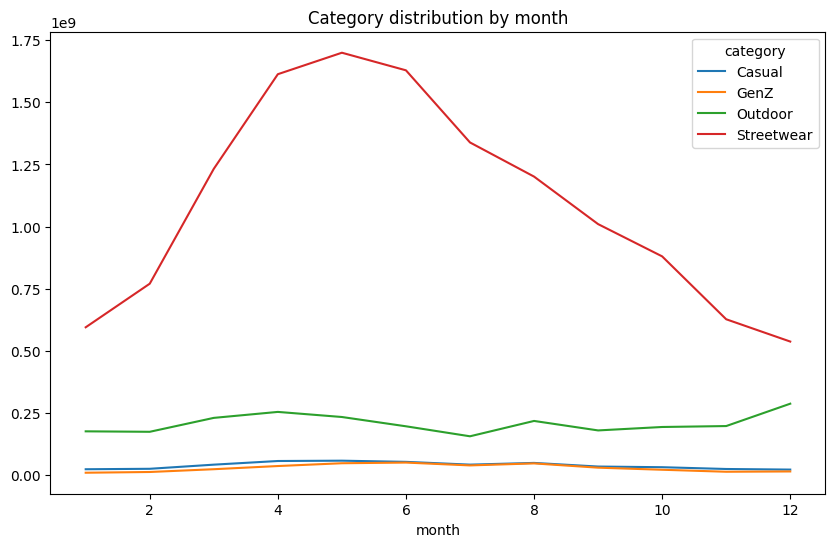


Revenue loss from returns: 905268284.96
Return loss %: 0.05509689753961565


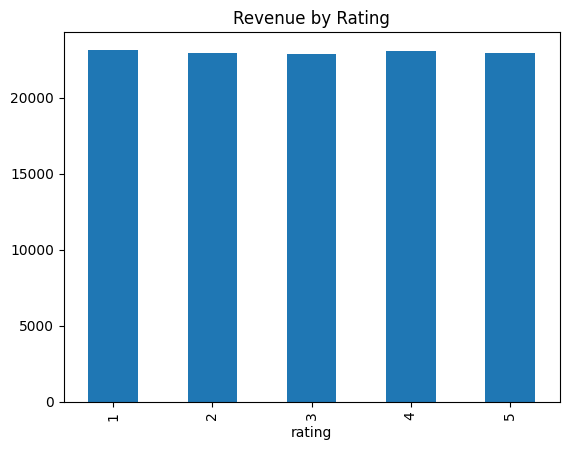


Lag correlation:
lag1: 0.3216062387954649
lag7: 0.3092020734637414

Average Order Value: 25397.02229019468

Revenue per session: 182.72308867537532


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =====================
# LOAD DATA
# =====================
orders = pd.read_csv(input_path + "orders.csv", parse_dates=["order_date"])
order_items = pd.read_csv(input_path + "order_items.csv")
products = pd.read_csv(input_path + "products.csv")
customers = pd.read_csv(input_path + "customers.csv")
payments = pd.read_csv(input_path + "payments.csv")
shipments = pd.read_csv(input_path + "shipments.csv", parse_dates=["ship_date","delivery_date"])
returns = pd.read_csv(input_path + "returns.csv")
reviews = pd.read_csv(input_path + "reviews.csv")
promotions = pd.read_csv(input_path + "promotions.csv", parse_dates=["start_date","end_date"])
web = pd.read_csv(input_path + "web_traffic.csv", parse_dates=["date"])
geography = pd.read_csv(input_path + "geography.csv")

orders = orders.rename(columns={"zip": "shipping_zip"})
customers = customers.rename(columns={"zip": "customer_zip"})

# =====================
# MERGE MASTER TABLE
# =====================
df = orders.merge(order_items, on="order_id")
df = df.merge(products, on="product_id")
df = df.merge(customers, on="customer_id")
df = df.merge(payments, on="order_id", how="left")
df = df.merge(shipments, on="order_id", how="left")
df = df.merge(geography, left_on="shipping_zip", right_on="zip", how="left")
# Revenue
df["revenue"] = df["quantity"] * df["unit_price"]

# Promotion flag
df["has_promo"] = df["promo_id"].notna()

# Installment flag
df["is_installment"] = df["installments"] > 1

# =====================
# 1. PROMOTION + INSTALLMENT IMPACT
# =====================
promo_effect = df.groupby(["has_promo","is_installment"])["revenue"].mean()
print("\nPromo + Installment effect:\n", promo_effect)

# =====================
# 2. TRAFFIC vs REVENUE
# =====================
daily_rev = df.groupby("order_date")["revenue"].sum().reset_index()
traffic = web.groupby("date")["sessions"].sum().reset_index()

merged = daily_rev.merge(traffic, left_on="order_date", right_on="date")

corr = merged["revenue"].corr(merged["sessions"])
print("\nTraffic vs Revenue correlation:", corr)

plt.figure()
plt.scatter(merged["sessions"], merged["revenue"])
plt.title("Traffic vs Revenue")
plt.xlabel("Sessions")
plt.ylabel("Revenue")
plt.show()

# =====================
# 3. WEEKEND / HOLIDAY EFFECT
# =====================
merged["dayofweek"] = merged["order_date"].dt.dayofweek
weekend_rev = merged.groupby("dayofweek")["revenue"].mean()

plt.figure()
weekend_rev.plot(kind="bar")
plt.title("Revenue by Day of Week")
plt.show()

# =====================
# 4. RETURN RATE (by category)
# =====================
returns_flag = returns[["order_id","product_id"]]

df["returned"] = df.set_index(["order_id","product_id"]).index.isin(
    returns_flag.set_index(["order_id","product_id"]).index
)

cat_return = df.groupby("category")["returned"].mean().sort_values(ascending=False)
print("\nReturn rate by category:\n", cat_return)

# =====================
# 5. INSTALLMENT vs RETURN
# =====================
install_return = df.groupby("is_installment")["returned"].mean()
print("\nReturn rate by installment:\n", install_return)

# =====================
# 6. GEOGRAPHY (region buying power)
# =====================
region_rev = df.groupby("region")["revenue"].sum().sort_values(ascending=False)

plt.figure()
region_rev.plot(kind="bar")
plt.title("Revenue by Region")
plt.show()

# =====================
# 7. SHIPPING TIME vs PURCHASE
# =====================
df["shipping_days"] = (df["delivery_date"] - df["ship_date"]).dt.days

ship_effect = df.groupby("shipping_days")["revenue"].mean()

plt.figure()
ship_effect.plot()
plt.title("Shipping time vs Revenue")
plt.show()

# =====================
# 8. PROMO TYPE EFFECT
# =====================
df = df.merge(promotions, on="promo_id", how="left")

promo_type_effect = df.groupby("promo_type")["revenue"].mean()
print("\nPromo type effect:\n", promo_type_effect)

# min_order_value impact
mov_effect = df.groupby(pd.cut(df["min_order_value"], bins=5))["revenue"].mean()
print("\nMin order value impact:\n", mov_effect)

# =====================
# 9. CATEGORY IN SALE PERIOD
# =====================
df["month"] = df["order_date"].dt.month

season_cat = df.groupby(["month","category"])["revenue"].sum().unstack()

season_cat.plot(figsize=(10,6))
plt.title("Category distribution by month")
plt.show()

# =====================
# 10. RETURNS IMPACT ON REVENUE
# =====================
loss = df[df["returned"] == True]["revenue"].sum()
total = df["revenue"].sum()

print("\nRevenue loss from returns:", loss)
print("Return loss %:", loss / total)

# =====================
# 11. REVIEW IMPACT
# =====================
review_df = reviews.merge(df, on=["order_id","product_id","customer_id"], how="left")

rating_effect = review_df.groupby("rating")["revenue"].mean()

plt.figure()
rating_effect.plot(kind="bar")
plt.title("Revenue by Rating")
plt.show()

# =====================
# 12. TRAFFIC LAG EFFECT (IMPORTANT)
# =====================
merged["lag_1"] = merged["sessions"].shift(1)
merged["lag_7"] = merged["sessions"].shift(7)

print("\nLag correlation:")
print("lag1:", merged["revenue"].corr(merged["lag_1"]))
print("lag7:", merged["revenue"].corr(merged["lag_7"]))

# =====================
# EXTRA (IMPORTANT INSIGHT)
# =====================
# AOV (average order value)
aov = df.groupby("order_id")["revenue"].sum().mean()
print("\nAverage Order Value:", aov)

# Conversion proxy
merged["rev_per_session"] = merged["revenue"] / merged["sessions"]
print("\nRevenue per session:", merged["rev_per_session"].mean())

In [14]:
# =====================
# IMPORT
# =====================
import pandas as pd
import numpy as np
import plotly.express as px
from IPython.display import display

# =====================
# LOAD DATA
# =====================
input_path = "/kaggle/input/datasets/luquang231/datathonvinu/"

orders = pd.read_csv(input_path + "orders.csv", parse_dates=["order_date"])
order_items = pd.read_csv(input_path + "order_items.csv")
products = pd.read_csv(input_path + "products.csv")
customers = pd.read_csv(input_path + "customers.csv")
payments = pd.read_csv(input_path + "payments.csv")
shipments = pd.read_csv(input_path + "shipments.csv", parse_dates=["ship_date","delivery_date"])
returns = pd.read_csv(input_path + "returns.csv")
reviews = pd.read_csv(input_path + "reviews.csv")
promotions = pd.read_csv(input_path + "promotions.csv", parse_dates=["start_date","end_date"])
web = pd.read_csv(input_path + "web_traffic.csv", parse_dates=["date"])
geography = pd.read_csv(input_path + "geography.csv")

orders = orders.rename(columns={"zip": "shipping_zip"})
customers = customers.rename(columns={"zip": "customer_zip"})

# =====================
# MERGE DATA
# =====================
df = orders.merge(order_items, on="order_id")
df = df.merge(products, on="product_id")
df = df.merge(customers, on="customer_id")
df = df.merge(payments, on="order_id", how="left")
df = df.merge(shipments, on="order_id", how="left")
df = df.merge(geography, left_on="shipping_zip", right_on="zip", how="left")

df["revenue"] = df["quantity"] * df["unit_price"]
df["has_promo"] = df["promo_id"].notna()
df["is_installment"] = df["installments"] > 1
df["month"] = df["order_date"].dt.month
df["dayofweek"] = df["order_date"].dt.dayofweek

# Return flag
returns_flag = returns[["order_id","product_id"]]
df["returned"] = df.set_index(["order_id","product_id"]).index.isin(
    returns_flag.set_index(["order_id","product_id"]).index
)

# =====================
# KPI
# =====================
print("===== KPI =====")
print("Total Revenue:", df["revenue"].sum())
print("Avg Order Value:", df.groupby("order_id")["revenue"].sum().mean())
print("Return Rate:", df["returned"].mean())
print("Installment Usage:", df["is_installment"].mean())

# =====================
# REVENUE OVER TIME
# =====================
daily_rev = df.groupby("order_date")["revenue"].sum().reset_index()

fig1 = px.line(daily_rev, x="order_date", y="revenue", title="Revenue Over Time")
fig1.show()

# =====================
# TRAFFIC VS REVENUE
# =====================
traffic = web.groupby("date")["sessions"].sum().reset_index()
merged = daily_rev.merge(traffic, left_on="order_date", right_on="date")

fig2 = px.scatter(merged, x="sessions", y="revenue", title="Traffic vs Revenue")
fig2.show()

print("Correlation traffic-revenue:", merged["revenue"].corr(merged["sessions"]))

# =====================
# CATEGORY PERFORMANCE
# =====================
cat_rev = df.groupby("category")["revenue"].sum().reset_index()

fig3 = px.bar(cat_rev, x="category", y="revenue", title="Revenue by Category")
fig3.show()

# =====================
# RETURN RATE BY CATEGORY
# =====================
cat_return = df.groupby("category")["returned"].mean().reset_index()

fig4 = px.bar(cat_return, x="category", y="returned", title="Return Rate by Category")
fig4.show()

# =====================
# PROMO + INSTALLMENT EFFECT
# =====================
promo_effect = df.groupby(["has_promo","is_installment"])["revenue"].mean().reset_index()

fig5 = px.bar(
    promo_effect,
    x="has_promo",
    y="revenue",
    color="is_installment",
    barmode="group",
    title="Promo + Installment Effect"
)
fig5.show()

# =====================
# REGION PERFORMANCE
# =====================
region_rev = df.groupby("region")["revenue"].sum().reset_index()

fig6 = px.bar(region_rev, x="region", y="revenue", title="Revenue by Region")
fig6.show()

# =====================
# SHIPPING TIME IMPACT
# =====================
df["shipping_days"] = (df["delivery_date"] - df["ship_date"]).dt.days

ship_effect = df.groupby("shipping_days")["revenue"].mean().reset_index()

fig7 = px.line(ship_effect, x="shipping_days", y="revenue", title="Shipping Time Impact")
fig7.show()

# =====================
# SEASONALITY
# =====================
season = df.groupby("month")["revenue"].mean().reset_index()

fig8 = px.bar(season, x="month", y="revenue", title="Seasonality (Monthly)")
fig8.show()

# =====================
# EXTRA: LAG TRAFFIC
# =====================
merged["lag_1"] = merged["sessions"].shift(1)
merged["lag_7"] = merged["sessions"].shift(7)

print("Lag1 corr:", merged["revenue"].corr(merged["lag_1"]))
print("Lag7 corr:", merged["revenue"].corr(merged["lag_7"]))

# =====================
# LOSS FROM RETURNS
# =====================
loss = df[df["returned"]]["revenue"].sum()
print("Revenue loss from returns:", loss)
print("Loss %:", loss / df["revenue"].sum())

/tmp/ipykernel_55/3509632707.py:15: DtypeWarning:

Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.



===== KPI =====
Total Revenue: 16430476585.529993
Avg Order Value: 25397.02229019468
Return Rate: 0.05588461231703068
Installment Usage: 0.593501327187831


Correlation traffic-revenue: 0.32105016128466324


Lag1 corr: 0.3216062387954649
Lag7 corr: 0.3092020734637414
Revenue loss from returns: 905268284.96
Loss %: 0.05509689753961565


In [16]:
import plotly.express as px

# =====================
# PREP DATA
# =====================
promo_df = promotions.copy()

# duration
promo_df["duration_days"] = (promo_df["end_date"] - promo_df["start_date"]).dt.days

# sort theo start_date cho đẹp
promo_df = promo_df.sort_values("start_date")

# =====================
# PLOT TIMELINE
# =====================
fig = px.timeline(
    promo_df,
    x_start="start_date",
    x_end="end_date",
    y="promo_name",
    color="promo_type",
    title="📅 Promotion Timeline",
    hover_data=["discount_value", "duration_days", "promo_channel"]
)

fig.update_yaxes(autorange="reversed")  # để promo mới ở trên
fig.show()

# count số promo active mỗi ngày
date_range = pd.date_range(promo_df["start_date"].min(), promo_df["end_date"].max())

active_counts = []

for d in date_range:
    count = ((promo_df["start_date"] <= d) & (promo_df["end_date"] >= d)).sum()
    active_counts.append(count)

overlap_df = pd.DataFrame({
    "date": date_range,
    "active_promos": active_counts
})

fig2 = px.line(overlap_df, x="date", y="active_promos",
               title="🔥 Number of Active Promotions Over Time")

fig2.show()

fig3 = px.histogram(
    promo_df,
    x="duration_days",
    nbins=20,
    title="Distribution of Promotion Duration"
)

fig3.show()

In [17]:
import pandas as pd
import numpy as np
import plotly.express as px

# =====================
# PREP PROMO
# =====================
promo_df = promotions.copy()
promo_df["duration_days"] = (promo_df["end_date"] - promo_df["start_date"]).dt.days

# =====================
# 1. ACTIVE PROMOS (OVERLAP)
# =====================
date_range = pd.date_range(promo_df["start_date"].min(), promo_df["end_date"].max())

active_counts = []
for d in date_range:
    count = ((promo_df["start_date"] <= d) & (promo_df["end_date"] >= d)).sum()
    active_counts.append(count)

overlap_df = pd.DataFrame({
    "date": date_range,
    "active_promos": active_counts
})

fig1 = px.line(overlap_df, x="date", y="active_promos",
               title="🔥 Number of Active Promotions Over Time")
fig1.show()

# =====================
# 2. MERGE REVENUE
# =====================
daily_rev = df.groupby("order_date")["revenue"].sum().reset_index()

overlap_rev = overlap_df.merge(daily_rev, left_on="date", right_on="order_date", how="left")

fig2 = px.scatter(
    overlap_rev,
    x="active_promos",
    y="revenue",
    title="Active Promotions vs Revenue"
)
fig2.show()

print("Correlation (promo overlap vs revenue):",
      overlap_rev["active_promos"].corr(overlap_rev["revenue"]))

# =====================
# 3. MERGE TRAFFIC
# =====================
traffic = web.groupby("date")["sessions"].sum().reset_index()

overlap_all = overlap_df.merge(traffic, on="date", how="left")

fig3 = px.scatter(
    overlap_all,
    x="active_promos",
    y="sessions",
    title="Active Promotions vs Traffic"
)
fig3.show()

print("Correlation (promo overlap vs traffic):",
      overlap_all["active_promos"].corr(overlap_all["sessions"]))

# =====================
# 4. PROMO DURATION VS EFFECT
# =====================
# gắn revenue trung bình vào từng promo
promo_effect = []

for _, row in promo_df.iterrows():
    mask = (df["order_date"] >= row["start_date"]) & (df["order_date"] <= row["end_date"])
    avg_rev = df.loc[mask, "revenue"].mean()
    promo_effect.append(avg_rev)

promo_df["avg_revenue_during_promo"] = promo_effect

fig4 = px.scatter(
    promo_df,
    x="duration_days",
    y="avg_revenue_during_promo",
    color="promo_type",
    title="Promo Duration vs Avg Revenue"
)
fig4.show()

# =====================
# 5. SEASONAL PROMO
# =====================
promo_df["start_month"] = promo_df["start_date"].dt.month

fig5 = px.histogram(
    promo_df,
    x="start_month",
    title="Promo Distribution by Month"
)
fig5.show()

# =====================
# 6. REVENUE BY MONTH (SO SÁNH)
# =====================
df["month"] = df["order_date"].dt.month
monthly_rev = df.groupby("month")["revenue"].mean().reset_index()

fig6 = px.bar(
    monthly_rev,
    x="month",
    y="revenue",
    title="Revenue Seasonality"
)
fig6.show()

Correlation (promo overlap vs revenue): -0.10535154746668413


Correlation (promo overlap vs traffic): -0.05338720324136403


Việc chạy nhiều chương trình khuyến mãi cùng lúc không làm tăng doanh thu đáng kể, cho thấy hiện tượng cannibalization (các chương trình cạnh tranh lẫn nhau).



In [18]:
import plotly.express as px

# =====================
# 1. DAILY REVENUE (2012–2022)
# =====================
daily_rev = df.groupby("order_date")["revenue"].sum().reset_index()

fig1 = px.line(
    daily_rev,
    x="order_date",
    y="revenue",
    title="📈 Daily Revenue (2012–2022)"
)

fig1.show()


# =====================
# 2. MONTHLY REVENUE (TREND + SEASONALITY)
# =====================
df["year_month"] = df["order_date"].dt.to_period("M").astype(str)

monthly_rev = df.groupby("year_month")["revenue"].sum().reset_index()

fig2 = px.line(
    monthly_rev,
    x="year_month",
    y="revenue",
    title="📊 Monthly Revenue Trend"
)

fig2.update_xaxes(tickangle=45)
fig2.show()


# =====================
# 3. BONUS: MONTH SEASONALITY (AVERAGE)
# =====================
df["month"] = df["order_date"].dt.month

month_avg = df.groupby("month")["revenue"].mean().reset_index()

fig3 = px.bar(
    month_avg,
    x="month",
    y="revenue",
    title="🔥 Average Revenue by Month (Seasonality)"
)

fig3.show()

In [19]:
daily_rev["rolling_7"] = daily_rev["revenue"].rolling(7).mean()

fig4 = px.line(daily_rev, x="order_date", y=["revenue","rolling_7"],
               title="Daily Revenue + 7-day Moving Average")

fig4.show()